# 02 Financial Ratio Analysis

In this notebook, I analyze Tata Motors' financial ratios from FY2021 to FY2025.  
My objective is to understand how the company performed across profitability, liquidity, solvency, efficiency, and cash-flow strength.

This notebook uses the cleaned datasets that I prepared earlier and converts them into business insights that can later support the Power BI dashboard, final report, and CV project explanation.

## 1. Import libraries and set file paths

In this step, I import the libraries required for analysis and visualization. I also define the project folders so that the notebook can read cleaned files and save analysis outputs in the correct locations.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "cleaned"
REPORTS_DIR = PROJECT_ROOT / "reports"
CHARTS_DIR = REPORTS_DIR / "charts"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data folder:", DATA_DIR)
print("Reports folder:", REPORTS_DIR)
print("Charts folder:", CHARTS_DIR)

Project root: D:\Github Project\Tata Motors Financial Analysis
Cleaned data folder: D:\Github Project\Tata Motors Financial Analysis\data\cleaned
Reports folder: D:\Github Project\Tata Motors Financial Analysis\reports
Charts folder: D:\Github Project\Tata Motors Financial Analysis\reports\charts


## 2. Load the cleaned datasets

Here, I load the main cleaned datasets that were created from Tata Motors' consolidated financial statements. I use the ratio file as the primary dataset and keep the income statement, balance sheet, and cash-flow files available for cross-checking.

In [2]:
ratio_path = DATA_DIR / "financial_ratios.csv"
income_path = DATA_DIR / "income_statement_combined_FY2021_to_FY2025.csv"
balance_path = DATA_DIR / "balance_sheet_combined_FY2021_to_FY2025.csv"
cashflow_path = DATA_DIR / "cash_flow_statement_combined_FY2021_to_FY2025.csv"

required_files = [ratio_path, income_path, balance_path, cashflow_path]
missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError("These required files are missing: " + ", ".join(missing_files))

ratios = pd.read_csv(ratio_path)
income = pd.read_csv(income_path)
balance = pd.read_csv(balance_path)
cashflow = pd.read_csv(cashflow_path)

print("Ratios shape:", ratios.shape)
print("Income statement shape:", income.shape)
print("Balance sheet shape:", balance.shape)
print("Cash flow shape:", cashflow.shape)

display(ratios.head())

Ratios shape: (5, 35)
Income statement shape: (5, 35)
Balance sheet shape: (5, 58)
Cash flow shape: (5, 31)


,financial_year,revenue_from_operations_cr,total_income_cr,profit_before_tax_cr,profit_after_tax_cr,total_assets_cr,total_equity_cr,total_liabilities_cr,current_assets_cr,current_liabilities_cr,cash_and_cash_equivalents_cr,current_investments_cr,total_borrowings_cr,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,capex_payments_cr,net_profit_margin_pct,pbt_margin_pct,expense_to_income_ratio_pct,return_on_assets_pct,return_on_equity_pct,asset_turnover_ratio,current_ratio,quick_ratio,cash_ratio,working_capital_cr,debt_to_equity_ratio,debt_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct,capex_to_revenue_pct,source_income_statement,source_balance_sheet,source_cash_flow,notes
0,FY2020-21,249794.75,252437.94,-10474.28,-13395.10,343125.80,56820.21,286305.59,146887.64,157749.18,31700.01,19051.19,114775.56,29000.51,5317.00,-20205.40,-5.36,-4.19,98.70,-3.90,-23.57,0.73,0.93,0.70,0.32,-10861.54,2.02,0.83,11.61,2.13,8.09,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
1,FY2021-22,278453.62,281507.25,-7003.41,-11308.76,330619.93,48832.30,281787.63,146977.54,150682.81,38159.01,22709.22,139677.04,14282.83,-9254.00,-15168.42,-4.06,-2.52,102.26,-3.36,-21.41,0.83,0.98,0.74,0.40,-3705.27,2.86,0.85,5.13,-3.32,5.45,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
2,FY2022-23,345966.97,350600.15,3057.55,2689.87,336081.38,52599.51,283481.87,151528.47,155027.33,31886.95,18838.31,125660.47,35388.01,7840.00,-18095.68,0.78,0.88,99.58,0.81,5.30,1.04,0.98,0.71,0.33,-3498.86,2.39,0.84,10.23,2.27,5.23,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
3,FY2023-24,437927.77,443877.69,27955.11,31806.75,370663.96,93093.93,277570.03,168392.15,173617.00,40014.76,14253.24,98500.09,67915.36,26924.00,-31413.63,7.26,6.38,93.64,9.00,43.66,1.24,0.97,0.69,0.31,-5224.85,1.06,0.75,15.51,6.15,7.17,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
4,FY2024-25,439695.00,445939.00,33780.00,28149.00,378642.00,122754.00,255888.00,160325.00,166684.00,34349.00,27199.00,62499.00,63102.00,22348.00,-38042.00,6.40,7.68,92.37,7.51,26.08,1.17,0.96,0.68,0.37,-6359.00,0.51,0.68,14.35,5.08,8.65,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...


## 3. Standardize financial-year labels

I standardize the financial-year labels again to avoid issues such as `FY2020-21`, `FY2020_21`, and `FY2021` being treated as different years. This keeps the analysis consistent across all datasets.

In [3]:
def standardize_financial_year(value):
    value = str(value).strip()

    year_mapping = {
        "FY2020-21": "FY2021",
        "FY2020_21": "FY2021",
        "FY2021": "FY2021",
        "FY2021-22": "FY2022",
        "FY2021_22": "FY2022",
        "FY2022": "FY2022",
        "FY2022-23": "FY2023",
        "FY2022_23": "FY2023",
        "FY2023": "FY2023",
        "FY2023-24": "FY2024",
        "FY2023_24": "FY2024",
        "FY2024": "FY2024",
        "FY2024-25": "FY2025",
        "FY2024_25": "FY2025",
        "FY2025": "FY2025",
    }

    return year_mapping.get(value, value)

for df in [ratios, income, balance, cashflow]:
    df["financial_year"] = df["financial_year"].apply(standardize_financial_year)
    df.drop_duplicates(subset=["financial_year"], keep="last", inplace=True)
    df.sort_values("financial_year", inplace=True)
    df.reset_index(drop=True, inplace=True)

expected_years = ["FY2021", "FY2022", "FY2023", "FY2024", "FY2025"]
actual_years = ratios["financial_year"].tolist()

print("Financial years in ratio dataset:", actual_years)

if actual_years != expected_years:
    raise ValueError(f"Financial-year validation failed. Expected {expected_years}, but got {actual_years}")

Financial years in ratio dataset: ['FY2021', 'FY2022', 'FY2023', 'FY2024', 'FY2025']


## 4. Build a focused KPI view

The full ratio dataset has many columns. For analysis, I create a focused view containing the most important financial health indicators.

In [4]:
key_ratio_columns = [
    "financial_year",
    "revenue_from_operations_cr",
    "profit_after_tax_cr",
    "total_assets_cr",
    "total_equity_cr",
    "total_liabilities_cr",
    "net_cash_from_operating_activities_cr",
    "auto_free_cash_flow_cr",
    "net_profit_margin_pct",
    "return_on_assets_pct",
    "return_on_equity_pct",
    "current_ratio",
    "quick_ratio",
    "cash_ratio",
    "working_capital_cr",
    "debt_to_equity_ratio",
    "debt_ratio",
    "operating_cash_flow_margin_pct",
    "free_cash_flow_margin_pct",
    "asset_turnover_ratio",
]

missing_columns = [col for col in key_ratio_columns if col not in ratios.columns]
if missing_columns:
    raise KeyError("Missing expected columns in financial_ratios.csv: " + ", ".join(missing_columns))

kpi_view = ratios[key_ratio_columns].copy()
display(kpi_view)

,financial_year,revenue_from_operations_cr,profit_after_tax_cr,total_assets_cr,total_equity_cr,total_liabilities_cr,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,net_profit_margin_pct,return_on_assets_pct,return_on_equity_pct,current_ratio,quick_ratio,cash_ratio,working_capital_cr,debt_to_equity_ratio,debt_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct,asset_turnover_ratio
0,FY2021,249794.75,-13395.10,343125.80,56820.21,286305.59,29000.51,5317.00,-5.36,-3.90,-23.57,0.93,0.70,0.32,-10861.54,2.02,0.83,11.61,2.13,0.73
1,FY2022,278453.62,-11308.76,330619.93,48832.30,281787.63,14282.83,-9254.00,-4.06,-3.36,-21.41,0.98,0.74,0.40,-3705.27,2.86,0.85,5.13,-3.32,0.83
2,FY2023,345966.97,2689.87,336081.38,52599.51,283481.87,35388.01,7840.00,0.78,0.81,5.30,0.98,0.71,0.33,-3498.86,2.39,0.84,10.23,2.27,1.04
3,FY2024,437927.77,31806.75,370663.96,93093.93,277570.03,67915.36,26924.00,7.26,9.00,43.66,0.97,0.69,0.31,-5224.85,1.06,0.75,15.51,6.15,1.24
4,FY2025,439695.00,28149.00,378642.00,122754.00,255888.00,63102.00,22348.00,6.40,7.51,26.08,0.96,0.68,0.37,-6359.00,0.51,0.68,14.35,5.08,1.17


## 5. Calculate year-over-year growth

In this step, I calculate year-over-year growth for revenue, profit after tax, operating cash flow, and free cash flow. This helps me understand whether Tata Motors' growth is consistent or volatile across the five-year period.

In [5]:
growth_view = kpi_view[[
    "financial_year",
    "revenue_from_operations_cr",
    "profit_after_tax_cr",
    "net_cash_from_operating_activities_cr",
    "auto_free_cash_flow_cr",
]].copy()

growth_metrics = [
    "revenue_from_operations_cr",
    "profit_after_tax_cr",
    "net_cash_from_operating_activities_cr",
    "auto_free_cash_flow_cr",
]

for metric in growth_metrics:
    growth_view[f"{metric}_yoy_growth_pct"] = growth_view[metric].pct_change() * 100

# I round values for cleaner presentation in reports and dashboards.
growth_view = growth_view.round(2)
display(growth_view)

,financial_year,revenue_from_operations_cr,profit_after_tax_cr,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,revenue_from_operations_cr_yoy_growth_pct,profit_after_tax_cr_yoy_growth_pct,net_cash_from_operating_activities_cr_yoy_growth_pct,auto_free_cash_flow_cr_yoy_growth_pct
0,FY2021,249794.75,-13395.10,29000.51,5317.00,NaN,NaN,NaN,NaN
1,FY2022,278453.62,-11308.76,14282.83,-9254.00,11.47,-15.58,-50.75,-274.05
2,FY2023,345966.97,2689.87,35388.01,7840.00,24.25,-123.79,147.77,-184.72
3,FY2024,437927.77,31806.75,67915.36,26924.00,26.58,1082.46,91.92,243.42
4,FY2025,439695.00,28149.00,63102.00,22348.00,0.40,-11.50,-7.09,-17.00


## 6. Profitability analysis

Here, I analyze whether Tata Motors is converting revenue into profit efficiently. I focus on net profit margin, ROA, and ROE because these indicators show profitability from sales, assets, and shareholder equity.

,financial_year,net_profit_margin_pct,return_on_assets_pct,return_on_equity_pct
0,FY2021,-5.36,-3.90,-23.57
1,FY2022,-4.06,-3.36,-21.41
2,FY2023,0.78,0.81,5.30
3,FY2024,7.26,9.00,43.66
4,FY2025,6.40,7.51,26.08


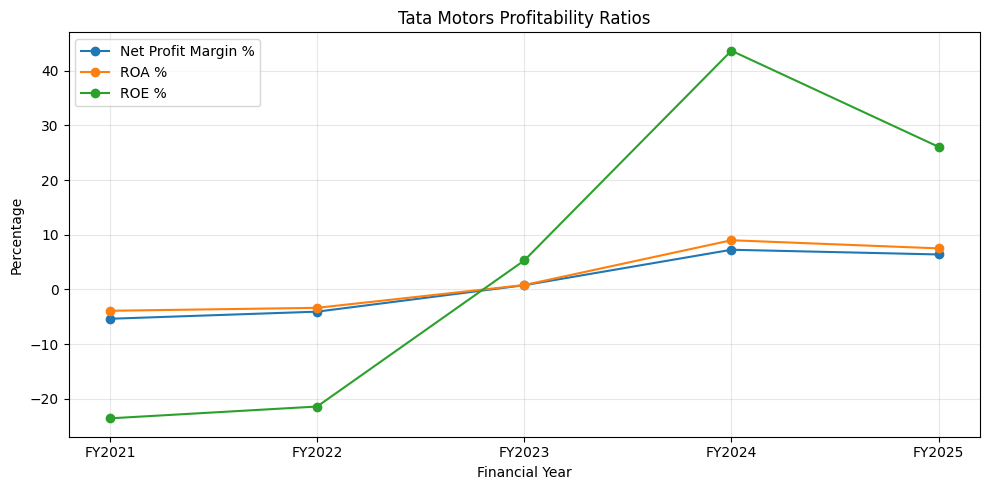

In [6]:
profitability_columns = [
    "financial_year",
    "net_profit_margin_pct",
    "return_on_assets_pct",
    "return_on_equity_pct",
]

profitability_view = kpi_view[profitability_columns].copy()
display(profitability_view)

plt.figure(figsize=(10, 5))
plt.plot(profitability_view["financial_year"], profitability_view["net_profit_margin_pct"], marker="o", label="Net Profit Margin %")
plt.plot(profitability_view["financial_year"], profitability_view["return_on_assets_pct"], marker="o", label="ROA %")
plt.plot(profitability_view["financial_year"], profitability_view["return_on_equity_pct"], marker="o", label="ROE %")
plt.title("Tata Motors Profitability Ratios")
plt.xlabel("Financial Year")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "profitability_ratios_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Liquidity analysis

In this step, I check whether Tata Motors has enough short-term assets to cover short-term liabilities. I use current ratio, quick ratio, cash ratio, and working capital.

,financial_year,current_ratio,quick_ratio,cash_ratio,working_capital_cr
0,FY2021,0.93,0.70,0.32,-10861.54
1,FY2022,0.98,0.74,0.40,-3705.27
2,FY2023,0.98,0.71,0.33,-3498.86
3,FY2024,0.97,0.69,0.31,-5224.85
4,FY2025,0.96,0.68,0.37,-6359.00


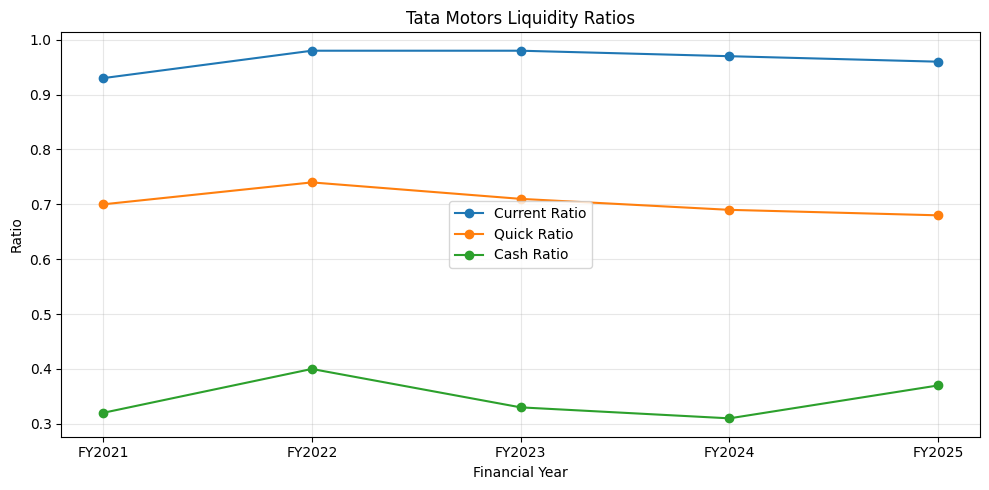

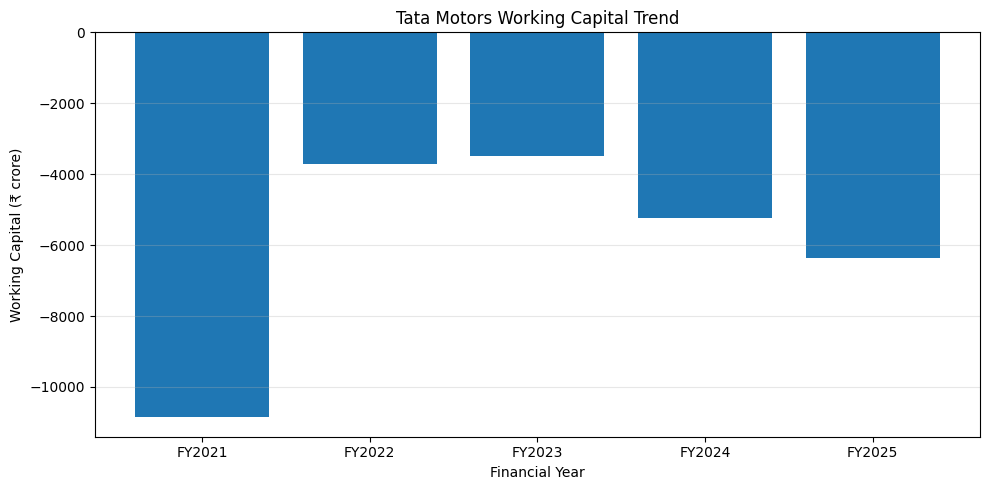

In [7]:
liquidity_columns = [
    "financial_year",
    "current_ratio",
    "quick_ratio",
    "cash_ratio",
    "working_capital_cr",
]

liquidity_view = kpi_view[liquidity_columns].copy()
display(liquidity_view)

plt.figure(figsize=(10, 5))
plt.plot(liquidity_view["financial_year"], liquidity_view["current_ratio"], marker="o", label="Current Ratio")
plt.plot(liquidity_view["financial_year"], liquidity_view["quick_ratio"], marker="o", label="Quick Ratio")
plt.plot(liquidity_view["financial_year"], liquidity_view["cash_ratio"], marker="o", label="Cash Ratio")
plt.title("Tata Motors Liquidity Ratios")
plt.xlabel("Financial Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "liquidity_ratios_trend.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(liquidity_view["financial_year"], liquidity_view["working_capital_cr"])
plt.title("Tata Motors Working Capital Trend")
plt.xlabel("Financial Year")
plt.ylabel("Working Capital (₹ crore)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "working_capital_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Solvency and debt analysis

Here, I analyze debt risk using debt-to-equity ratio and debt ratio. This helps me understand whether Tata Motors' financial structure became stronger or weaker over time.

,financial_year,total_liabilities_cr,total_equity_cr,debt_to_equity_ratio,debt_ratio
0,FY2021,286305.59,56820.21,2.02,0.83
1,FY2022,281787.63,48832.30,2.86,0.85
2,FY2023,283481.87,52599.51,2.39,0.84
3,FY2024,277570.03,93093.93,1.06,0.75
4,FY2025,255888.00,122754.00,0.51,0.68


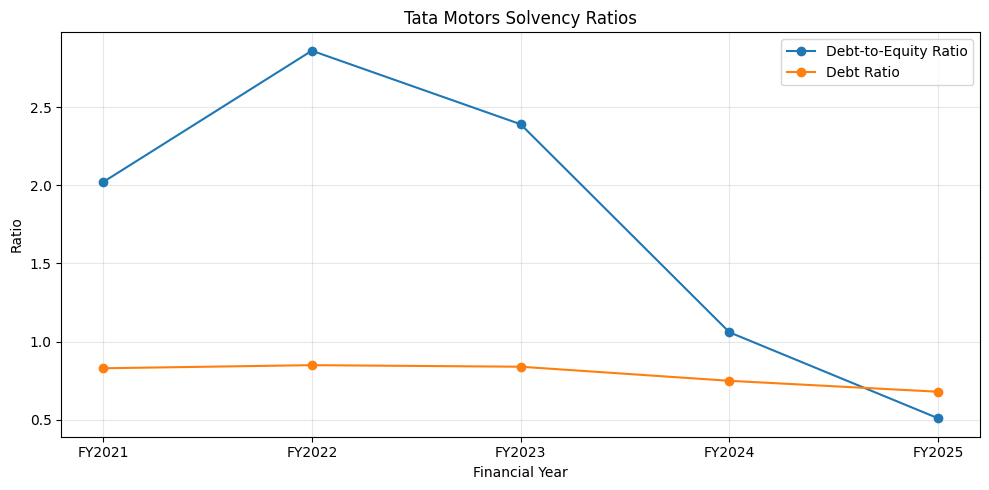

In [8]:
solvency_columns = [
    "financial_year",
    "total_liabilities_cr",
    "total_equity_cr",
    "debt_to_equity_ratio",
    "debt_ratio",
]

solvency_view = kpi_view[solvency_columns].copy()
display(solvency_view)

plt.figure(figsize=(10, 5))
plt.plot(solvency_view["financial_year"], solvency_view["debt_to_equity_ratio"], marker="o", label="Debt-to-Equity Ratio")
plt.plot(solvency_view["financial_year"], solvency_view["debt_ratio"], marker="o", label="Debt Ratio")
plt.title("Tata Motors Solvency Ratios")
plt.xlabel("Financial Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "solvency_ratios_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Cash-flow analysis

In this section, I analyze cash-flow strength using operating cash flow margin and free cash flow margin. This is important because a company can report profit but still face pressure if cash generation is weak.

,financial_year,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,operating_cash_flow_margin_pct,free_cash_flow_margin_pct
0,FY2021,29000.51,5317.00,11.61,2.13
1,FY2022,14282.83,-9254.00,5.13,-3.32
2,FY2023,35388.01,7840.00,10.23,2.27
3,FY2024,67915.36,26924.00,15.51,6.15
4,FY2025,63102.00,22348.00,14.35,5.08


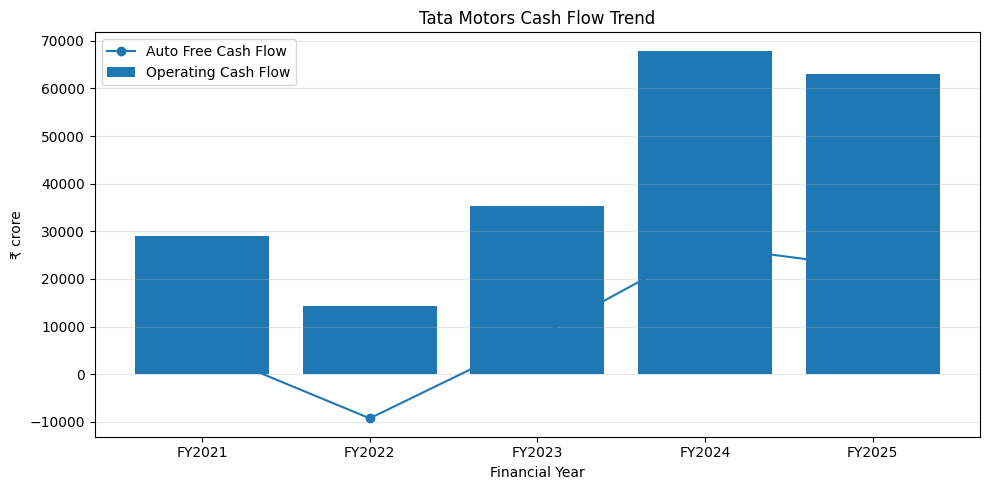

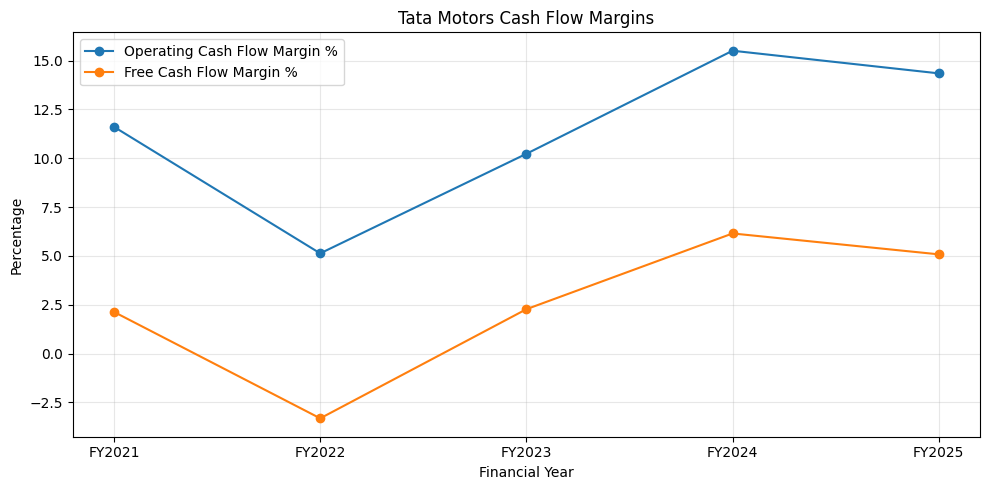

In [9]:
cashflow_analysis_columns = [
    "financial_year",
    "net_cash_from_operating_activities_cr",
    "auto_free_cash_flow_cr",
    "operating_cash_flow_margin_pct",
    "free_cash_flow_margin_pct",
]

cashflow_view = kpi_view[cashflow_analysis_columns].copy()
display(cashflow_view)

plt.figure(figsize=(10, 5))
plt.bar(cashflow_view["financial_year"], cashflow_view["net_cash_from_operating_activities_cr"], label="Operating Cash Flow")
plt.plot(cashflow_view["financial_year"], cashflow_view["auto_free_cash_flow_cr"], marker="o", label="Auto Free Cash Flow")
plt.title("Tata Motors Cash Flow Trend")
plt.xlabel("Financial Year")
plt.ylabel("₹ crore")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "cash_flow_trend.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cashflow_view["financial_year"], cashflow_view["operating_cash_flow_margin_pct"], marker="o", label="Operating Cash Flow Margin %")
plt.plot(cashflow_view["financial_year"], cashflow_view["free_cash_flow_margin_pct"], marker="o", label="Free Cash Flow Margin %")
plt.title("Tata Motors Cash Flow Margins")
plt.xlabel("Financial Year")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "cash_flow_margins_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Revenue and profit trend

I compare revenue and profit after tax to see whether revenue growth translated into bottom-line improvement.

,financial_year,revenue_from_operations_cr,profit_after_tax_cr
0,FY2021,249794.75,-13395.10
1,FY2022,278453.62,-11308.76
2,FY2023,345966.97,2689.87
3,FY2024,437927.77,31806.75
4,FY2025,439695.00,28149.00


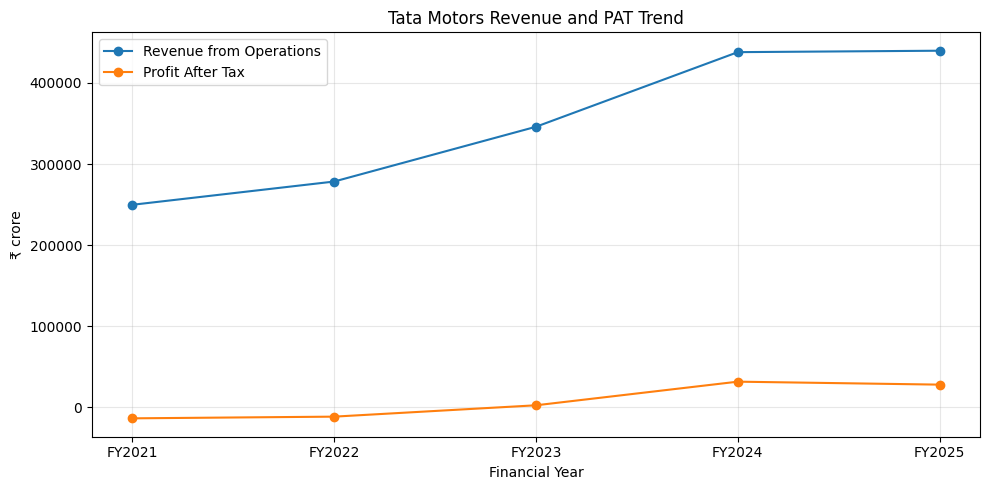

In [10]:
revenue_profit_view = kpi_view[[
    "financial_year",
    "revenue_from_operations_cr",
    "profit_after_tax_cr",
]].copy()

display(revenue_profit_view)

plt.figure(figsize=(10, 5))
plt.plot(revenue_profit_view["financial_year"], revenue_profit_view["revenue_from_operations_cr"], marker="o", label="Revenue from Operations")
plt.plot(revenue_profit_view["financial_year"], revenue_profit_view["profit_after_tax_cr"], marker="o", label="Profit After Tax")
plt.title("Tata Motors Revenue and PAT Trend")
plt.xlabel("Financial Year")
plt.ylabel("₹ crore")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "revenue_pat_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Create a business-health scorecard

I create a simple scorecard to summarize performance direction. This is not a credit rating or investment recommendation. It is a project-level analytical scorecard that helps me explain business health in a structured way.

,financial_year,net_profit_margin_pct,return_on_assets_pct,return_on_equity_pct,current_ratio,debt_to_equity_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct,profitability_score,asset_efficiency_score,shareholder_return_score,liquidity_score,debt_score,cashflow_score,fcf_score,business_health_score,max_possible_score,business_health_score_pct
0,FY2021,-5.36,-3.90,-23.57,0.93,2.02,11.61,2.13,0,0,0,1,0,2,1,4,14,28.57
1,FY2022,-4.06,-3.36,-21.41,0.98,2.86,5.13,-3.32,0,0,0,1,0,1,0,2,14,14.29
2,FY2023,0.78,0.81,5.30,0.98,2.39,10.23,2.27,0,0,1,1,0,2,1,5,14,35.71
3,FY2024,7.26,9.00,43.66,0.97,1.06,15.51,6.15,2,2,2,1,1,2,2,12,14,85.71
4,FY2025,6.40,7.51,26.08,0.96,0.51,14.35,5.08,2,2,2,1,2,2,2,13,14,92.86


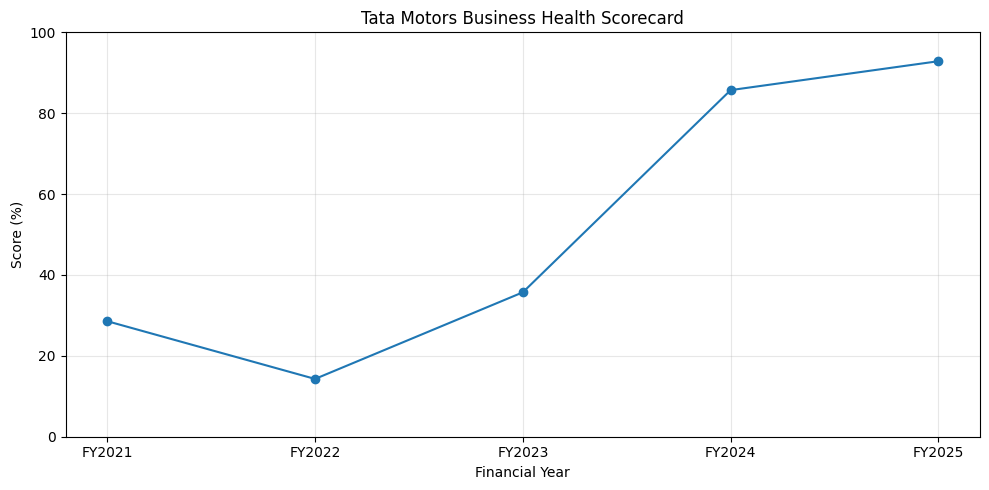

In [11]:
scorecard = kpi_view[[
    "financial_year",
    "net_profit_margin_pct",
    "return_on_assets_pct",
    "return_on_equity_pct",
    "current_ratio",
    "debt_to_equity_ratio",
    "operating_cash_flow_margin_pct",
    "free_cash_flow_margin_pct",
]].copy()

def score_positive(value, strong_threshold, moderate_threshold):
    if pd.isna(value):
        return np.nan
    if value >= strong_threshold:
        return 2
    if value >= moderate_threshold:
        return 1
    return 0

def score_lower_is_better(value, strong_threshold, moderate_threshold):
    if pd.isna(value):
        return np.nan
    if value <= strong_threshold:
        return 2
    if value <= moderate_threshold:
        return 1
    return 0

scorecard["profitability_score"] = scorecard["net_profit_margin_pct"].apply(lambda x: score_positive(x, 5, 1))
scorecard["asset_efficiency_score"] = scorecard["return_on_assets_pct"].apply(lambda x: score_positive(x, 5, 1))
scorecard["shareholder_return_score"] = scorecard["return_on_equity_pct"].apply(lambda x: score_positive(x, 15, 5))
scorecard["liquidity_score"] = scorecard["current_ratio"].apply(lambda x: score_positive(x, 1.2, 0.9))
scorecard["debt_score"] = scorecard["debt_to_equity_ratio"].apply(lambda x: score_lower_is_better(x, 1.0, 2.0))
scorecard["cashflow_score"] = scorecard["operating_cash_flow_margin_pct"].apply(lambda x: score_positive(x, 10, 5))
scorecard["fcf_score"] = scorecard["free_cash_flow_margin_pct"].apply(lambda x: score_positive(x, 5, 1))

score_columns = [
    "profitability_score",
    "asset_efficiency_score",
    "shareholder_return_score",
    "liquidity_score",
    "debt_score",
    "cashflow_score",
    "fcf_score",
]

scorecard["business_health_score"] = scorecard[score_columns].sum(axis=1)
scorecard["max_possible_score"] = len(score_columns) * 2
scorecard["business_health_score_pct"] = (scorecard["business_health_score"] / scorecard["max_possible_score"] * 100).round(2)

display(scorecard)

plt.figure(figsize=(10, 5))
plt.plot(scorecard["financial_year"], scorecard["business_health_score_pct"], marker="o")
plt.title("Tata Motors Business Health Scorecard")
plt.xlabel("Financial Year")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "business_health_scorecard.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Generate automated insight flags

I create simple insight flags to identify the strongest and weakest areas. These flags will help me write the final business insights report and dashboard commentary.

In [12]:
latest_year = kpi_view.iloc[-1]
previous_year = kpi_view.iloc[-2]

insights = []

revenue_change = ((latest_year["revenue_from_operations_cr"] / previous_year["revenue_from_operations_cr"]) - 1) * 100
pat_change = ((latest_year["profit_after_tax_cr"] / previous_year["profit_after_tax_cr"]) - 1) * 100 if previous_year["profit_after_tax_cr"] != 0 else np.nan

insights.append({
    "insight_area": "Revenue",
    "observation": f"Revenue changed by {revenue_change:.2f}% from {previous_year['financial_year']} to {latest_year['financial_year']}.",
})

insights.append({
    "insight_area": "Profitability",
    "observation": f"Net profit margin in {latest_year['financial_year']} was {latest_year['net_profit_margin_pct']:.2f}%.",
})

insights.append({
    "insight_area": "Liquidity",
    "observation": f"Current ratio in {latest_year['financial_year']} was {latest_year['current_ratio']:.2f}, indicating the short-term liquidity position.",
})

insights.append({
    "insight_area": "Debt",
    "observation": f"Debt-to-equity ratio in {latest_year['financial_year']} was {latest_year['debt_to_equity_ratio']:.2f}.",
})

insights.append({
    "insight_area": "Cash Flow",
    "observation": f"Operating cash flow margin in {latest_year['financial_year']} was {latest_year['operating_cash_flow_margin_pct']:.2f}% and free cash flow margin was {latest_year['free_cash_flow_margin_pct']:.2f}%.",
})

insight_flags = pd.DataFrame(insights)
display(insight_flags)

,insight_area,observation
0,Revenue,Revenue changed by 0.40% from FY2024 to FY2025.
1,Profitability,Net profit margin in FY2025 was 6.40%.
2,Liquidity,"Current ratio in FY2025 was 0.96, indicating t..."
3,Debt,Debt-to-equity ratio in FY2025 was 0.51.
4,Cash Flow,Operating cash flow margin in FY2025 was 14.35...


## 13. Save analysis outputs

I save the key analysis tables so that I can use them later in Excel, Power BI, the final report, and GitHub documentation.

In [13]:
ratio_analysis_summary_path = REPORTS_DIR / "financial_ratio_analysis_summary.csv"
growth_summary_path = REPORTS_DIR / "financial_growth_summary.csv"
scorecard_path = REPORTS_DIR / "business_health_scorecard.csv"
insight_flags_path = REPORTS_DIR / "financial_insight_flags.csv"

kpi_view.to_csv(ratio_analysis_summary_path, index=False)
growth_view.to_csv(growth_summary_path, index=False)
scorecard.to_csv(scorecard_path, index=False)
insight_flags.to_csv(insight_flags_path, index=False)

print("Saved ratio analysis summary to:", ratio_analysis_summary_path)
print("Saved growth summary to:", growth_summary_path)
print("Saved business health scorecard to:", scorecard_path)
print("Saved insight flags to:", insight_flags_path)
print("Charts saved in:", CHARTS_DIR)

Saved ratio analysis summary to: D:\Github Project\Tata Motors Financial Analysis\reports\financial_ratio_analysis_summary.csv
Saved growth summary to: D:\Github Project\Tata Motors Financial Analysis\reports\financial_growth_summary.csv
Saved business health scorecard to: D:\Github Project\Tata Motors Financial Analysis\reports\business_health_scorecard.csv
Saved insight flags to: D:\Github Project\Tata Motors Financial Analysis\reports\financial_insight_flags.csv
Charts saved in: D:\Github Project\Tata Motors Financial Analysis\reports\charts


## 14. Final conclusion from this notebook

At this stage, I have converted the cleaned financial statement datasets into ratio-based analysis outputs. The saved tables and charts will help me build the next parts of the project: Excel ratio model, SQL analysis, Power BI dashboard, and final business insights report.